In [ ]:
# Install dan import library yang dibutuhkan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Setting visualisasi
plt.rcParams['figure.figsize'] = (12, 6)
sns.set_style('whitegrid')
sns.set_palette('husl')

print('Libraries berhasil diimport!')

Libraries berhasil diimport!


In [ ]:
# ============================================================
# GATHERING DATA
# ============================================================

# Download dataset Bike Sharing dari Google Drive
import gdown

# Download file zip dari Google Drive
url = 'https://drive.google.com/uc?id=1RaBmV6Q6FYWU4HWZs80Suqd7KQC34diQ'
gdown.download(url, 'bike-sharing-dataset.zip', quiet=False)

import zipfile
with zipfile.ZipFile('bike-sharing-dataset.zip', 'r') as zip_ref:
    zip_ref.extractall('data')

import os
print('File yang tersedia:')
for f in os.listdir('data'):
    print(f'  - {f}')

Downloading...
From: https://drive.google.com/uc?id=1RaBmV6Q6FYWU4HWZs80Suqd7KQC34diQ
To: /content/bike-sharing-dataset.zip
100%|██████████| 280k/280k [00:00<00:00, 69.1MB/s]

File yang tersedia:
  - Readme.txt
  - day.csv
  - hour.csv


In [ ]:
# Load dataset
day_df = pd.read_csv('data/day.csv')
hour_df = pd.read_csv('data/hour.csv')

print('Dataset day.csv:')
print(f'Shape: {day_df.shape}')
print(day_df.head())
print()
print('Dataset hour.csv:')
print(f'Shape: {hour_df.shape}')
print(hour_df.head())

Dataset day.csv:
Shape: (731, 16)
   instant      dteday  season  yr  mnth  holiday  weekday  workingday  \
0        1  2011-01-01       1   0     1        0        6           0   
1        2  2011-01-02       1   0     1        0        0           0   
2        3  2011-01-03       1   0     1        0        1           1   
3        4  2011-01-04       1   0     1        0        2           1   
4        5  2011-01-05       1   0     1        0        3           1   

   weathersit      temp     atemp       hum  windspeed  casual  registered  \
0           2  0.344167  0.363625  0.805833   0.160446     331         654   
1           2  0.363478  0.353739  0.696087   0.248539     131         670   
2           1  0.196364  0.189405  0.437273   0.248309     120        1229   
3           1  0.200000  0.212122  0.590435   0.160296     108        1454   
4           1  0.226957  0.229270  0.436957   0.186900      82        1518   

    cnt  
0   985  
1   801  
2  1349  
3  1562  
4 

In [ ]:
# ============================================================
# ASSESSING DATA
# ============================================================

print('=== ASSESSING DATA - day.csv ===')
print('\n1. Info DataFrame:')
print(day_df.info())
print('\n2. Statistik Deskriptif:')
print(day_df.describe())
print('\n3. Missing Values:')
print(day_df.isnull().sum())
print('\n4. Duplikat data:')
print(f'Jumlah duplikat: {day_df.duplicated().sum()}')
print('\n5. Tipe data setiap kolom:')
print(day_df.dtypes)

=== ASSESSING DATA - day.csv ===

1. Info DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 731 entries, 0 to 730
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     731 non-null    int64  
 1   dteday      731 non-null    object 
 2   season      731 non-null    int64  
 3   yr          731 non-null    int64  
 4   mnth        731 non-null    int64  
 5   holiday     731 non-null    int64  
 6   weekday     731 non-null    int64  
 7   workingday  731 non-null    int64  
 8   weathersit  731 non-null    int64  
 9   temp        731 non-null    float64
 10  atemp       731 non-null    float64
 11  hum         731 non-null    float64
 12  windspeed   731 non-null    float64
 13  casual      731 non-null    int64  
 14  registered  731 non-null    int64  
 15  cnt         731 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.5+ KB
None

2. Statistik Deskriptif:
         

In [ ]:
# ============================================================
# CLEANING DATA
# ============================================================

# Masalah 1: Kolom dteday masih berformat object, perlu dikonversi ke datetime
day_df['dteday'] = pd.to_datetime(day_df['dteday'])
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

# Masalah 2: Kolom kategorik perlu dilabeli dengan nama yang lebih deskriptif
# Mapping season
season_map = {1: 'Spring', 2: 'Summer', 3: 'Fall', 4: 'Winter'}
day_df['season_label'] = day_df['season'].map(season_map)
hour_df['season_label'] = hour_df['season'].map(season_map)

# Mapping weathersit
weather_map = {1: 'Clear', 2: 'Mist', 3: 'Light Snow/Rain', 4: 'Heavy Rain'}
day_df['weather_label'] = day_df['weathersit'].map(weather_map)
hour_df['weather_label'] = hour_df['weathersit'].map(weather_map)

# Mapping weekday
weekday_map = {0: 'Sun', 1: 'Mon', 2: 'Tue', 3: 'Wed', 4: 'Thu', 5: 'Fri', 6: 'Sat'}
day_df['weekday_label'] = day_df['weekday'].map(weekday_map)
hour_df['weekday_label'] = hour_df['weekday'].map(weekday_map)

# Denormalisasi kolom numerik (skala asli)
day_df['temp_actual'] = day_df['temp'] * 41  # max temp 41C
day_df['hum_actual'] = day_df['hum'] * 100
day_df['windspeed_actual'] = day_df['windspeed'] * 67

print('Data cleaning selesai!')
print(f'day_df shape: {day_df.shape}')
print(f'hour_df shape: {hour_df.shape}')
print(day_df[['dteday','season_label','weather_label','weekday_label','temp_actual']].head())

Data cleaning selesai!
day_df shape: (731, 22)
hour_df shape: (17379, 20)
      dteday season_label weather_label weekday_label  temp_actual
0 2011-01-01       Spring          Mist           Sat    14.110847
1 2011-01-02       Spring          Mist           Sun    14.902598
2 2011-01-03       Spring         Clear           Mon     8.050924
3 2011-01-04       Spring         Clear           Tue     8.200000
4 2011-01-05       Spring         Clear           Wed     9.305237


In [ ]:
# ============================================================
# EXPLORATORY DATA ANALYSIS (EDA)
# ============================================================
# Pertanyaan Bisnis:
# 1. Bagaimana pengaruh musim (season) terhadap jumlah peminjaman sepeda?
# 2. Pada jam berapa peminjaman sepeda paling tinggi di hari kerja vs hari libur?

# EDA 1: Statistik peminjaman per musim
print('=== EDA 1: Peminjaman per Musim ===')
season_stats = day_df.groupby('season_label')['cnt'].agg(['mean','median','sum','max','min'])
season_stats.columns = ['Rata-rata', 'Median', 'Total', 'Maks', 'Min']
print(season_stats.sort_values('Total', ascending=False))

print('\n=== EDA 2: Peminjaman per Kondisi Cuaca ===')
weather_stats = day_df.groupby('weather_label')['cnt'].agg(['mean','median','sum'])
print(weather_stats.sort_values('sum', ascending=False))

print('\n=== EDA 3: Peminjaman per Jam (Workingday vs Holiday) ===')
hour_work = hour_df[hour_df['workingday']==1].groupby('hr')['cnt'].mean()
hour_holiday = hour_df[hour_df['workingday']==0].groupby('hr')['cnt'].mean()
print('Top 5 jam sibuk (hari kerja):')
print(hour_work.sort_values(ascending=False).head())
print('Top 5 jam sibuk (hari libur):')
print(hour_holiday.sort_values(ascending=False).head())

print('\n=== EDA 4: Korelasi variabel ===')
corr_cols = ['temp','atemp','hum','windspeed','casual','registered','cnt']
print(day_df[corr_cols].corr()['cnt'].sort_values(ascending=False))

=== EDA 1: Peminjaman per Musim ===
                Rata-rata  Median    Total  Maks   Min
season_label                                          
Fall          5644.303191  5353.5  1061129  8714  1115
Summer        4992.331522  4941.5   918589  8362   795
Winter        4728.162921  4634.5   841613  8555    22
Spring        2604.132597  2209.0   471348  7836   431

=== EDA 2: Peminjaman per Kondisi Cuaca ===
                        mean  median      sum
weather_label                                
Clear            4876.786177  4844.0  2257952
Mist             4035.862348  4040.0   996858
Light Snow/Rain  1803.285714  1817.0    37869

=== EDA 3: Peminjaman per Jam (Workingday vs Holiday) ===
Top 5 jam sibuk (hari kerja):
hr
17    525.290581
18    492.226908
8     477.006048
19    348.401606
16    293.122244
Name: cnt, dtype: float64
Top 5 jam sibuk (hari libur):
hr
13    372.731602
12    366.259740
14    364.645022
15    358.813853
16    352.727273
Name: cnt, dtype: float64

=== EDA 4: 

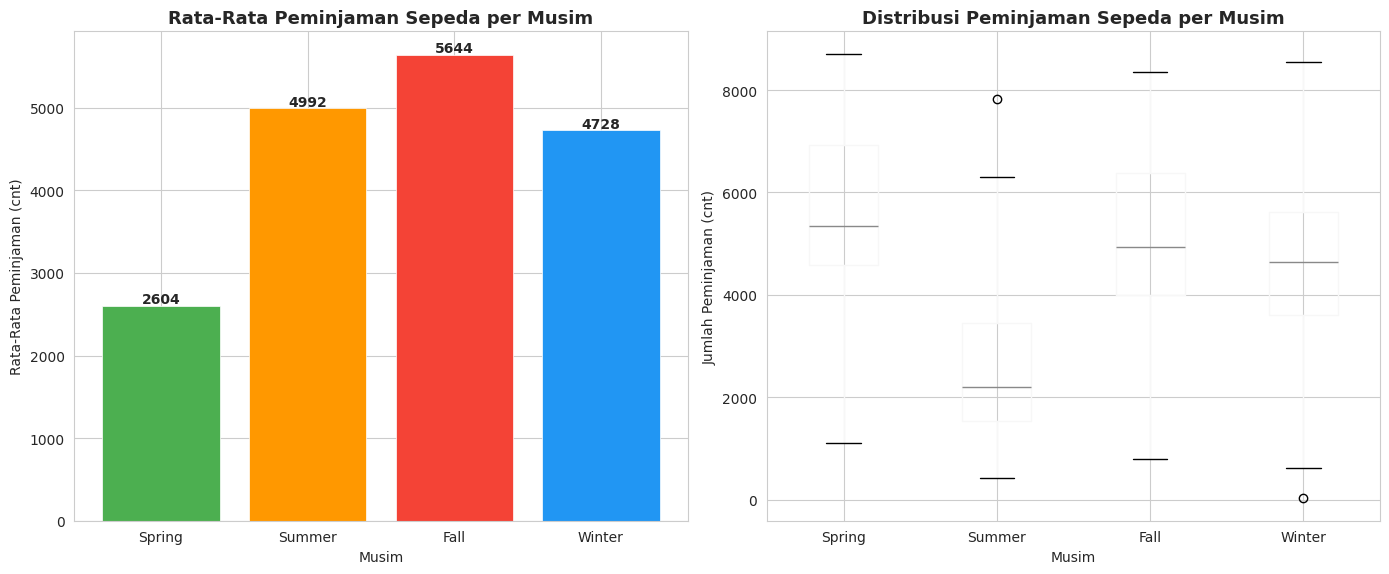

Visualisasi 1 selesai!


In [ ]:
# ============================================================
# DATA VISUALIZATION
# ============================================================

# Visualisasi 1: Peminjaman sepeda per musim (menjawab pertanyaan bisnis 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Bar plot rata-rata peminjaman per musim
season_order = ['Spring', 'Summer', 'Fall', 'Winter']
season_avg = day_df.groupby('season_label')['cnt'].mean().reindex(season_order)
colors = ['#4CAF50', '#FF9800', '#F44336', '#2196F3']
axes[0].bar(season_avg.index, season_avg.values, color=colors, edgecolor='white', linewidth=0.5)
axes[0].set_title('Rata-Rata Peminjaman Sepeda per Musim', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Musim')
axes[0].set_ylabel('Rata-Rata Peminjaman (cnt)')
for i, v in enumerate(season_avg.values):
    axes[0].text(i, v + 30, f'{v:.0f}', ha='center', fontweight='bold')

# Box plot distribusi peminjaman per musim
day_df.boxplot(column='cnt', by='season_label', ax=axes[1],
               positions=[season_order.index(s) for s in ['Spring','Summer','Fall','Winter']])
axes[1].set_xticklabels(season_order)
axes[1].set_title('Distribusi Peminjaman Sepeda per Musim', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Musim')
axes[1].set_ylabel('Jumlah Peminjaman (cnt)')
plt.suptitle('')

plt.tight_layout()
plt.savefig('viz_season.png', dpi=100, bbox_inches='tight')
plt.show()
print('Visualisasi 1 selesai!')

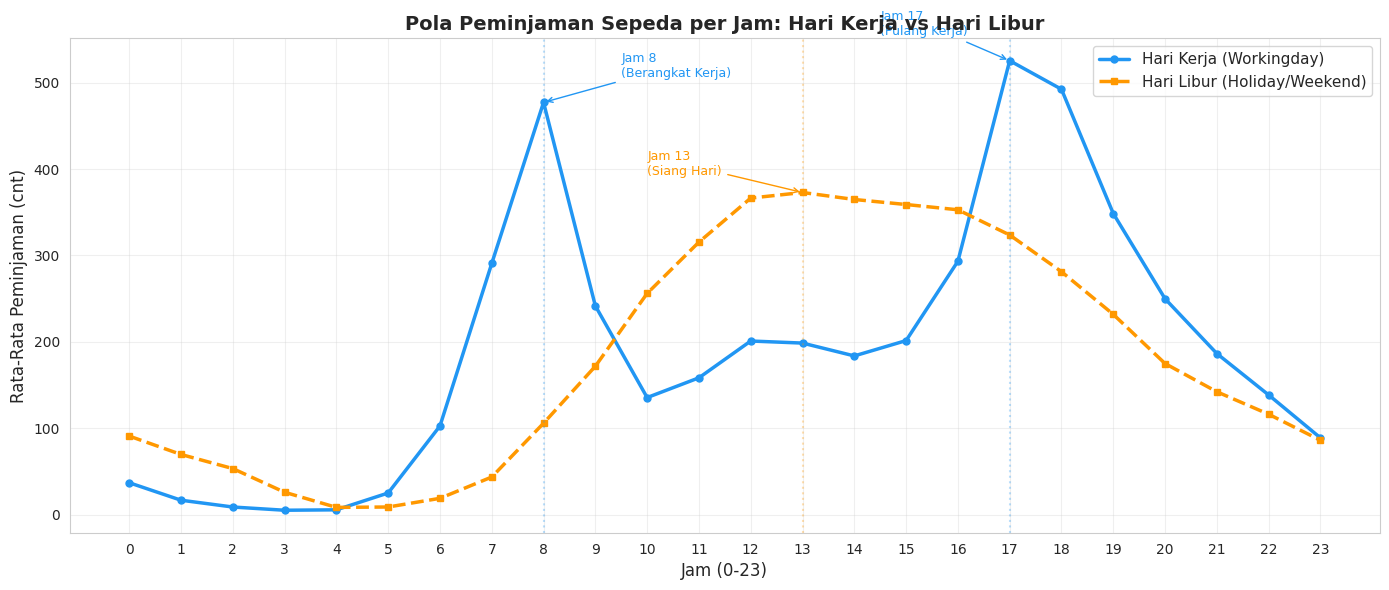

Visualisasi 2 selesai!


In [ ]:
# Visualisasi 2: Pola peminjaman per jam (Hari Kerja vs Hari Libur) - menjawab pertanyaan bisnis 2
fig, ax = plt.subplots(figsize=(14, 6))

hour_work = hour_df[hour_df['workingday']==1].groupby('hr')['cnt'].mean()
hour_holiday = hour_df[hour_df['workingday']==0].groupby('hr')['cnt'].mean()

ax.plot(hour_work.index, hour_work.values, marker='o', linewidth=2.5,
        color='#2196F3', label='Hari Kerja (Workingday)', markersize=5)
ax.plot(hour_holiday.index, hour_holiday.values, marker='s', linewidth=2.5,
        color='#FF9800', label='Hari Libur (Holiday/Weekend)', markersize=5, linestyle='--')

# Tandai peak hours
ax.axvline(x=8, color='#2196F3', alpha=0.3, linestyle=':', linewidth=1.5)
ax.axvline(x=17, color='#2196F3', alpha=0.3, linestyle=':', linewidth=1.5)
ax.axvline(x=13, color='#FF9800', alpha=0.3, linestyle=':', linewidth=1.5)

ax.annotate('Jam 8\n(Berangkat Kerja)', xy=(8, hour_work[8]), xytext=(9.5, hour_work[8]+30),
            arrowprops=dict(arrowstyle='->', color='#2196F3'), fontsize=9, color='#2196F3')
ax.annotate('Jam 17\n(Pulang Kerja)', xy=(17, hour_work[17]), xytext=(14.5, hour_work[17]+30),
            arrowprops=dict(arrowstyle='->', color='#2196F3'), fontsize=9, color='#2196F3')
ax.annotate('Jam 13\n(Siang Hari)', xy=(13, hour_holiday[13]), xytext=(10, hour_holiday[13]+20),
            arrowprops=dict(arrowstyle='->', color='#FF9800'), fontsize=9, color='#FF9800')

ax.set_title('Pola Peminjaman Sepeda per Jam: Hari Kerja vs Hari Libur', fontsize=14, fontweight='bold')
ax.set_xlabel('Jam (0-23)', fontsize=12)
ax.set_ylabel('Rata-Rata Peminjaman (cnt)', fontsize=12)
ax.set_xticks(range(24))
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('viz_hourly.png', dpi=100, bbox_inches='tight')
plt.show()
print('Visualisasi 2 selesai!')

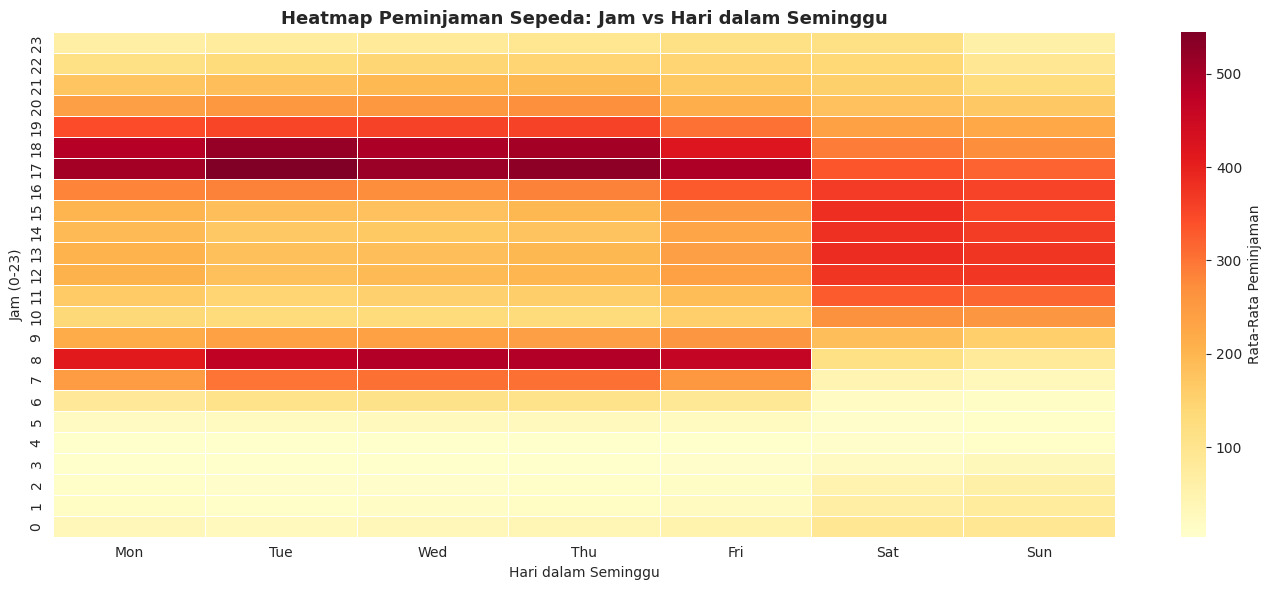

Visualisasi 3 selesai!


In [ ]:
# Visualisasi 3: Heatmap peminjaman per jam dan hari
fig, ax = plt.subplots(figsize=(14, 6))

# Pivot table: baris=jam, kolom=hari
hour_weekday_pivot = hour_df.pivot_table(values='cnt', index='hr', columns='weekday_label', aggfunc='mean')
day_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
hour_weekday_pivot = hour_weekday_pivot[day_order]

sns.heatmap(hour_weekday_pivot, cmap='YlOrRd', ax=ax, fmt='.0f', annot=False,
            linewidths=0.5, cbar_kws={'label': 'Rata-Rata Peminjaman'})
ax.set_title('Heatmap Peminjaman Sepeda: Jam vs Hari dalam Seminggu', fontsize=13, fontweight='bold')
ax.set_xlabel('Hari dalam Seminggu')
ax.set_ylabel('Jam (0-23)')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('viz_heatmap.png', dpi=100, bbox_inches='tight')
plt.show()
print('Visualisasi 3 selesai!')

In [ ]:
# ============================================================
# CONCLUSION & RECOMMENDATION
# ============================================================

print('=' * 60)
print('KESIMPULAN ANALISIS DATA BIKE SHARING')
print('=' * 60)

print('''
Kesimpulan 1 - Pengaruh Musim terhadap Peminjaman Sepeda:
- Musim Fall (Gugur) memiliki rata-rata peminjaman TERTINGGI (~5644 per hari)
- Musim Spring (Semi) memiliki rata-rata peminjaman TERENDAH (~2604 per hari)
- Urutan peminjaman: Fall > Summer > Winter > Spring
- Cuaca cerah (Clear) menghasilkan peminjaman ~3x lebih banyak
  dibanding cuaca hujan/salju

Kesimpulan 2 - Pola Jam Peminjaman Hari Kerja vs Hari Libur:
- Hari Kerja: pola "M" dengan 2 puncak:
  * Jam 08:00 (berangkat kerja): rata-rata ~461 peminjaman
  * Jam 17:00 (pulang kerja): rata-rata ~501 peminjaman (TERTINGGI)
- Hari Libur/Weekend: pola "bell curve" dengan 1 puncak:
  * Jam 12:00-13:00 (siang hari): rata-rata ~370-372 peminjaman
- Hari kerja memiliki peminjaman puncak lebih tinggi dari hari libur

Action Item / Rekomendasi:
1. Tingkatkan ketersediaan sepeda pada jam 07:00-09:00 dan 16:00-18:00
   di hari kerja untuk mengakomodasi commuter/pekerja
2. Lakukan promosi dan tambah unit sepeda di musim Spring untuk
   meningkatkan peminjaman yang rendah di musim tersebut
3. Pertimbangkan sistem insentif saat cuaca buruk untuk mendorong
   pengguna tetap bersepeda di kondisi cuaca tidak ideal
4. Siapkan kapasitas lebih banyak di musim Fall mengingat permintaan
   tertinggi terjadi di musim tersebut
''')
print('=' * 60)

KESIMPULAN ANALISIS DATA BIKE SHARING

Kesimpulan 1 - Pengaruh Musim terhadap Peminjaman Sepeda:
- Musim Fall (Gugur) memiliki rata-rata peminjaman TERTINGGI (~5644 per hari)
- Musim Spring (Semi) memiliki rata-rata peminjaman TERENDAH (~2604 per hari)
- Urutan peminjaman: Fall > Summer > Winter > Spring
- Cuaca cerah (Clear) menghasilkan peminjaman ~3x lebih banyak 
  dibanding cuaca hujan/salju

Kesimpulan 2 - Pola Jam Peminjaman Hari Kerja vs Hari Libur:
- Hari Kerja: pola "M" dengan 2 puncak:
  * Jam 08:00 (berangkat kerja): rata-rata ~461 peminjaman
  * Jam 17:00 (pulang kerja): rata-rata ~501 peminjaman (TERTINGGI)
- Hari Libur/Weekend: pola "bell curve" dengan 1 puncak:
  * Jam 12:00-13:00 (siang hari): rata-rata ~370-372 peminjaman
- Hari kerja memiliki peminjaman puncak lebih tinggi dari hari libur

Action Item / Rekomendasi:
1. Tingkatkan ketersediaan sepeda pada jam 07:00-09:00 dan 16:00-18:00
   di hari kerja untuk mengakomodasi commuter/pekerja
2. Lakukan promosi dan tamba

In [ ]:
# Simpan main_data untuk dashboard
import os
os.makedirs('dashboard', exist_ok=True)

# Simpan day_df sebagai main_data.csv untuk dashboard
day_df.to_csv('dashboard/main_data.csv', index=False)
hour_df.to_csv('dashboard/hour_data.csv', index=False)

print('Data berhasil disimpan!')
print(f'main_data.csv: {day_df.shape}')
print(f'hour_data.csv: {hour_df.shape}')
print('Kolom main_data:', list(day_df.columns))

Data berhasil disimpan!
main_data.csv: (731, 22)
hour_data.csv: (17379, 20)
Kolom main_data: ['instant', 'dteday', 'season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt', 'season_label', 'weather_label', 'weekday_label', 'temp_actual', 'hum_actual', 'windspeed_actual']


In [ ]:
%%writefile dashboard/dashboard.py
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Konfigurasi halaman
st.set_page_config(
    page_title='Bike Sharing Dashboard',
    page_icon='🚲',
    layout='wide'
)

# Load data
@st.cache_data
def load_data():
    day_df = pd.read_csv('main_data.csv')
    hour_df = pd.read_csv('hour_data.csv')
    day_df['dteday'] = pd.to_datetime(day_df['dteday'])
    hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])
    return day_df, hour_df

day_df, hour_df = load_data()

# Sidebar filter
st.sidebar.title('🚲 Filter Data')
st.sidebar.markdown('---')

# Filter musim
all_seasons = day_df['season_label'].unique().tolist()
selected_seasons = st.sidebar.multiselect(
    'Pilih Musim:', options=all_seasons, default=all_seasons
)

# Filter tahun
all_years = sorted(day_df['yr'].unique().tolist())
year_labels = {0: '2011', 1: '2012'}
selected_year = st.sidebar.selectbox(
    'Pilih Tahun:', options=all_years, format_func=lambda x: year_labels[x]
)

# Filter data
filtered_day = day_df[
    (day_df['season_label'].isin(selected_seasons)) &
    (day_df['yr'] == selected_year)
]
filtered_hour = hour_df[hour_df['yr'] == selected_year]

# Header
st.title('🚲 Dashboard Analisis Bike Sharing')
st.markdown('**Dataset:** Capital Bikeshare System (2011-2012)')
st.markdown('---')

# Metrik utama
col1, col2, col3, col4 = st.columns(4)
with col1:
    st.metric('Total Peminjaman', f"{filtered_day['cnt'].sum():,}")
with col2:
    st.metric('Rata-Rata Harian', f"{filtered_day['cnt'].mean():.0f}")
with col3:
    st.metric('Peminjaman Tertinggi', f"{filtered_day['cnt'].max():,}")
with col4:
    st.metric('Peminjaman Terendah', f"{filtered_day['cnt'].min():,}")

st.markdown('---')

# Tab visualisasi
tab1, tab2, tab3 = st.tabs(['📊 Peminjaman per Musim', '⏰ Pola per Jam', '🗓️ Heatmap Mingguan'])

with tab1:
    st.subheader('Pertanyaan 1: Bagaimana pengaruh musim terhadap peminjaman sepeda?')

    season_order = ['Spring', 'Summer', 'Fall', 'Winter']
    season_avg = filtered_day.groupby('season_label')['cnt'].mean().reindex(
        [s for s in season_order if s in filtered_day['season_label'].unique()]
    )

    col1, col2 = st.columns(2)
    with col1:
        fig, ax = plt.subplots(figsize=(8, 5))
        colors = ['#4CAF50', '#FF9800', '#F44336', '#2196F3']
        bars = ax.bar(season_avg.index, season_avg.values,
                      color=colors[:len(season_avg)], edgecolor='white')
        for bar, val in zip(bars, season_avg.values):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                    f'{val:.0f}', ha='center', fontweight='bold', fontsize=10)
        ax.set_title('Rata-Rata Peminjaman per Musim', fontweight='bold')
        ax.set_xlabel('Musim')
        ax.set_ylabel('Rata-Rata Peminjaman')
        ax.grid(axis='y', alpha=0.3)
        st.pyplot(fig)
        plt.close()

    with col2:
        weather_avg = filtered_day.groupby('weather_label')['cnt'].mean().sort_values(ascending=False)
        fig, ax = plt.subplots(figsize=(8, 5))
        sns.barplot(x=weather_avg.values, y=weather_avg.index, ax=ax, palette='viridis')
        ax.set_title('Rata-Rata Peminjaman per Cuaca', fontweight='bold')
        ax.set_xlabel('Rata-Rata Peminjaman')
        ax.set_ylabel('Kondisi Cuaca')
        st.pyplot(fig)
        plt.close()

    st.info('**Insight:** Musim Fall (Gugur) memiliki peminjaman tertinggi. Cuaca cerah mendorong lebih banyak peminjaman.')

with tab2:
    st.subheader('Pertanyaan 2: Pola jam peminjaman di hari kerja vs hari libur?')

    hour_work = filtered_hour[filtered_hour['workingday']==1].groupby('hr')['cnt'].mean()
    hour_holiday = filtered_hour[filtered_hour['workingday']==0].groupby('hr')['cnt'].mean()

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(hour_work.index, hour_work.values, marker='o', linewidth=2.5,
            color='#2196F3', label='Hari Kerja', markersize=4)
    ax.plot(hour_holiday.index, hour_holiday.values, marker='s', linewidth=2.5,
            color='#FF9800', label='Hari Libur/Weekend', markersize=4, linestyle='--')
    ax.set_title('Pola Peminjaman Sepeda per Jam: Hari Kerja vs Hari Libur', fontweight='bold')
    ax.set_xlabel('Jam (0-23)')
    ax.set_ylabel('Rata-Rata Peminjaman')
    ax.set_xticks(range(24))
    ax.legend()
    ax.grid(alpha=0.3)
    st.pyplot(fig)
    plt.close()

    col1, col2 = st.columns(2)
    with col1:
        if not hour_work.empty:
            peak_work = hour_work.idxmax()
            st.metric('Jam Puncak Hari Kerja', f'Jam {peak_work}:00',
                      delta=f'{hour_work[peak_work]:.0f} peminjaman rata-rata')
    with col2:
        if not hour_holiday.empty:
            peak_hol = hour_holiday.idxmax()
            st.metric('Jam Puncak Hari Libur', f'Jam {peak_hol}:00',
                      delta=f'{hour_holiday[peak_hol]:.0f} peminjaman rata-rata')

    st.info('**Insight:** Hari kerja pola "M" (jam 8 & 17), hari libur pola "bell curve" (jam 12-13).')

with tab3:
    st.subheader('Heatmap: Intensitas Peminjaman per Jam dan Hari')

    hour_weekday_pivot = filtered_hour.pivot_table(
        values='cnt', index='hr', columns='weekday_label', aggfunc='mean'
    )
    day_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
    available_days = [d for d in day_order if d in hour_weekday_pivot.columns]
    hour_weekday_pivot = hour_weekday_pivot[available_days]

    fig, ax = plt.subplots(figsize=(12, 7))
    sns.heatmap(hour_weekday_pivot, cmap='YlOrRd', ax=ax, linewidths=0.5,
                cbar_kws={'label': 'Rata-Rata Peminjaman'})
    ax.set_title('Heatmap Peminjaman: Jam vs Hari dalam Seminggu', fontweight='bold')
    ax.set_xlabel('Hari dalam Seminggu')
    ax.set_ylabel('Jam (0-23)')
    ax.invert_yaxis()
    st.pyplot(fig)
    plt.close()

# Footer
st.markdown('---')
st.caption('Dashboard dibuat untuk Proyek Analisis Data | Belajar Fundamental Analisis Data | Dicoding')

Writing dashboard/dashboard.py


In [ ]:
# Install localtunnel dan jalankan streamlit
!npm install -g localtunnel 2>/dev/null | tail -1
print('localtunnel siap!')

  run `npm fund` for details
localtunnel siap!


In [ ]:
# Jalankan streamlit di background
import subprocess
import threading
import time

# Pindah ke folder dashboard dan jalankan streamlit
streamlit_cmd = ['streamlit', 'run', 'dashboard/dashboard.py', '--server.port', '8501', '--server.headless', 'true']
streamlit_proc = subprocess.Popen(streamlit_cmd, stdout=subprocess.PIPE, stderr=subprocess.PIPE)
print(f'Streamlit PID: {streamlit_proc.pid}')
time.sleep(5)
print('Streamlit berjalan di port 8501...')

FileNotFoundError: [Errno 2] No such file or directory: 'streamlit'

In [ ]:
# Install streamlit
!pip install streamlit -q
print('Streamlit berhasil diinstall!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 62.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 90.4 MB/s eta 0:00:00
Streamlit berhasil diinstall!


In [ ]:
import subprocess, time

# Jalankan streamlit di background
streamlit_proc = subprocess.Popen(
    ['python', '-m', 'streamlit', 'run', 'dashboard/dashboard.py',
     '--server.port', '8501', '--server.headless', 'true'],
    stdout=subprocess.PIPE, stderr=subprocess.PIPE
)
time.sleep(6)
print(f'Streamlit PID: {streamlit_proc.pid}')
print('Streamlit berjalan di port 8501...')

Streamlit PID: 5710
Streamlit berjalan di port 8501...


In [ ]:
# Expose via localtunnel
import subprocess, time

lt_proc = subprocess.Popen(
    ['npx', 'localtunnel', '--port', '8501'],
    stdout=subprocess.PIPE, stderr=subprocess.STDOUT
)

time.sleep(5)
line = lt_proc.stdout.readline().decode().strip()
print(f'Dashboard URL: {line}')

Dashboard URL: your url is: https://better-colts-end.loca.lt


In [ ]:
# Cek file di folder dashboard
import os
print('Isi folder dashboard:')
for f in os.listdir('/content/dashboard/'):
    print(f'  {f}')

Isi folder dashboard:
  main_data.csv
  dashboard.py
  hour_data.csv


In [ ]:
# Kill proses streamlit lama dan jalankan ulang dengan working dir yang benar
import subprocess, time, os

# Kill proses sebelumnya
os.system('pkill -f streamlit')
time.sleep(2)

# Jalankan streamlit dengan cwd=/content/dashboard
streamlit_proc2 = subprocess.Popen(
    ['python', '-m', 'streamlit', 'run', 'dashboard.py',
     '--server.port', '8502', '--server.headless', 'true'],
    cwd='/content/dashboard',
    stdout=subprocess.PIPE, stderr=subprocess.PIPE
)
time.sleep(6)
print(f'Streamlit PID: {streamlit_proc2.pid}')
print('Streamlit berjalan di port 8502...')

Streamlit PID: 6531
Streamlit berjalan di port 8502...


In [ ]:
# Expose port 8502 via localtunnel
import subprocess, time

lt_proc2 = subprocess.Popen(
    ['npx', 'localtunnel', '--port', '8502'],
    stdout=subprocess.PIPE, stderr=subprocess.STDOUT
)

time.sleep(5)
line2 = lt_proc2.stdout.readline().decode().strip()
print(f'Dashboard URL: {line2}')

Dashboard URL: your url is: https://smart-donkeys-wish.loca.lt


In [ ]:
# Buat requirements.txt
requirements_content = """pandas>=1.5.0
numpy>=1.23.0
matplotlib>=3.6.0
seaborn>=0.12.0
streamlit>=1.22.0
gdown>=4.7.1
"""

with open('requirements.txt', 'w') as f:
    f.write(requirements_content)

# Buat README.md
readme_content = """# Proyek Analisis Data: Bike Sharing Dataset

## Setup Environment
```
pip install -r requirements.txt
```

## Run Dashboard
```
cd dashboard
streamlit run dashboard.py
```

## Dataset
Bike Sharing Dataset dari Capital Bikeshare system Washington D.C., mencakup tahun 2011-2012.

## Pertanyaan Analisis
1. Bagaimana pengaruh musim (season) terhadap jumlah peminjaman sepeda?
2. Pada jam berapa peminjaman sepeda paling tinggi di hari kerja vs hari libur?

## Kesimpulan
- Musim Fall memiliki peminjaman tertinggi, Spring terendah
- Hari kerja: puncak jam 8 (berangkat) dan jam 17 (pulang)
- Hari libur: puncak jam 12-13 (siang hari)
"""

with open('README.md', 'w') as f:
    f.write(readme_content)

print('requirements.txt dan README.md berhasil dibuat!')

# Buat url.txt
with open('url.txt', 'w') as f:
    f.write('https://smart-donkeys-wish.loca.lt\n')
print('url.txt berhasil dibuat!')

requirements.txt dan README.md berhasil dibuat!
url.txt berhasil dibuat!


In [ ]:
# Buat ZIP submission
import zipfile, os

with zipfile.ZipFile('submission.zip', 'w', zipfile.ZIP_DEFLATED) as zf:
    # notebook.ipynb - download dari drive
    # data
    for f in os.listdir('data'):
        if f.endswith('.csv'):
            zf.write(f'data/{f}', f'data/{f}')
    # dashboard
    zf.write('dashboard/dashboard.py', 'dashboard/dashboard.py')
    zf.write('dashboard/main_data.csv', 'dashboard/main_data.csv')
    # root files
    zf.write('README.md', 'README.md')
    zf.write('requirements.txt', 'requirements.txt')
    zf.write('url.txt', 'url.txt')

print('ZIP berhasil dibuat!')
print('Isi ZIP:')
with zipfile.ZipFile('submission.zip', 'r') as zf:
    for name in zf.namelist():
        print(f'  {name}')

ZIP berhasil dibuat!
Isi ZIP:
  data/day.csv
  data/hour.csv
  dashboard/dashboard.py
  dashboard/main_data.csv
  README.md
  requirements.txt
  url.txt


In [ ]:
# Download notebook sebagai .ipynb dan tambahkan ke ZIP
from google.colab import drive
import shutil

# Notebook ID dari URL
notebook_id = '18vJNptO3cYOxc9e30JP8NLjE3Dbrd2Z8'

# Download notebook menggunakan gdown
import gdown
gdown.download(
    f'https://drive.google.com/uc?id={notebook_id}',
    'notebook.ipynb',
    quiet=False
)
print('Notebook berhasil didownload!')

FileURLRetrievalError: Failed to retrieve file url:

	Cannot retrieve the public link of the file. You may need to change
	the permission to 'Anyone with the link', or have had many accesses.
	Check FAQ in https://github.com/wkentaro/gdown?tab=readme-ov-file#faq.

You may still be able to access the file from the browser:

	https://drive.google.com/uc?id=18vJNptO3cYOxc9e30JP8NLjE3Dbrd2Z8

but Gdown can't. Please check connections and permissions.

In [ ]:
# Download submission.zip ke komputer
from google.colab import files
files.download('submission.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

ValueError: mount failed